Predicting Fuel Efficiency

In [2]:
# import libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline
import requests 
import seaborn as sns
from sklearn.metrics import accuracy_score
import string 
import re 

In [10]:
# Import the data into a dataframe 
data = pd.read_csv("auto-mpg.csv")
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [12]:
# Count of rows/columns
data.shape

(398, 9)

In [13]:
# Count of missing values 
data.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [14]:
data.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [15]:
# Drop car name column from dataframe 
data = data.drop(columns=['car name'])
# Verify column removal
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130,3504,12.0,70,1
1,15.0,8,350.0,165,3693,11.5,70,1
2,18.0,8,318.0,150,3436,11.0,70,1
3,16.0,8,304.0,150,3433,12.0,70,1
4,17.0,8,302.0,140,3449,10.5,70,1


In [16]:
# Convert horsepower to numeric -  NaN
data['horsepower'] = pd.to_numeric(data['horsepower'], errors='coerce')

In [17]:
# Validate the datatype of the horsepower column
data.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model year        int64
origin            int64
dtype: object

In [18]:
# Verify NaN values in horsepower column 
data.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
dtype: int64

In [20]:
# Calculate the mean of the column, skipping NaNs
hp_mean = data['horsepower'].mean()
# View mean result
hp_mean

np.float64(104.46938775510205)

In [21]:
# Fill missing vales with the mean 
data['horsepower'] = data['horsepower'].fillna(hp_mean)
data.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
dtype: int64

In [ ]:
# Confirm there are no missing values 
data.isna().sum()

In [23]:
# Create dummy variables for origin column 
origin_dummies = pd.get_dummies(data['origin'], prefix='origin')

In [24]:
# Concatenate with the original DataFrame
data = pd.concat([data, origin_dummies], axis=1)

In [18]:
# View first 5 rows 
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,origin_1,origin_2,origin_3
0,18.0,8,307.0,130.0,3504,12.0,70,1,True,False,False
1,15.0,8,350.0,165.0,3693,11.5,70,1,True,False,False
2,18.0,8,318.0,150.0,3436,11.0,70,1,True,False,False
3,16.0,8,304.0,150.0,3433,12.0,70,1,True,False,False
4,17.0,8,302.0,140.0,3449,10.5,70,1,True,False,False


In [25]:
# Correlation matrix 
correlation_matrix = data.corr(numeric_only=True)

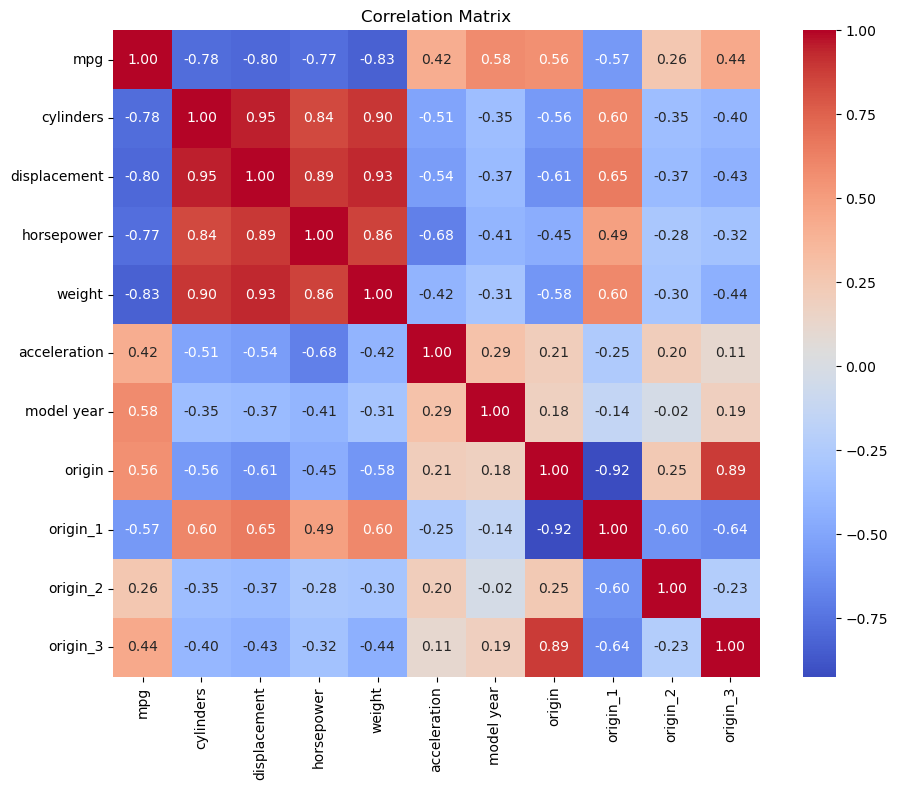

In [26]:
# Heatmap visualization of correlation 
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Matrix')
plt.tight_layout()

MPG Correlation Insights
* Weight - There is a strong negative correlation – heavier cars get worse mileage
* Cylinders - More cylinders = lower MPG
* Displacement - Bigger engines reduce efficiency

In [27]:
# Extract correlations with mpg
mpg_correlations = correlation_matrix['mpg'].sort_values(ascending=False)
mpg_correlations

mpg             1.000000
model year      0.579267
origin          0.563450
origin_3        0.442174
acceleration    0.420289
origin_2        0.259022
origin_1       -0.568192
horsepower     -0.771437
cylinders      -0.775396
displacement   -0.804203
weight         -0.831741
Name: mpg, dtype: float64

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

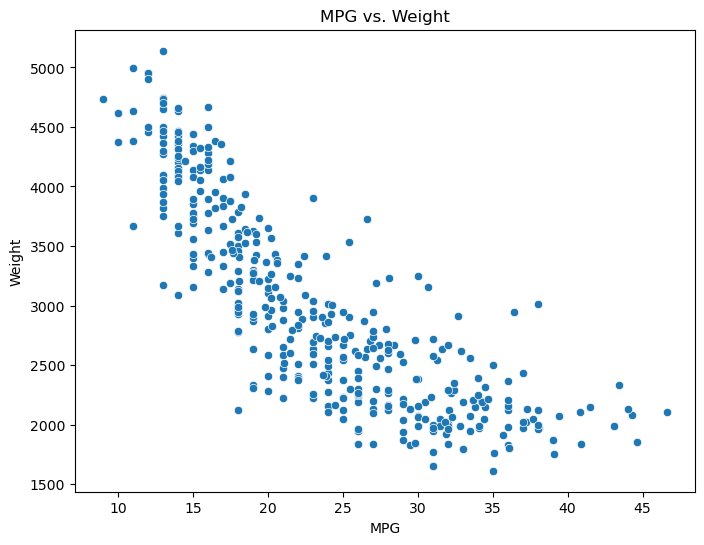

In [28]:
# Plot weight vs. mpg 
plt.figure(figsize=(8,6))
sns.scatterplot(x='mpg', y='weight', data=data)
plt.title("MPG vs. Weight")
plt.xlabel("MPG")
plt.ylabel("Weight")
plt.tight_layout

In [29]:
# Import libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [30]:
# Define features x and target y
X = data.drop(columns=['mpg'])
y = data['mpg']

In [31]:
# Split the test & training data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 #20% of the data in the test 
)

In [32]:
# Initialize the linear regression model
lin_reg = LinearRegression()

# Fit the model on training data
lin_reg.fit(X_train, y_train)

LinearRegression()

In [33]:
# Predict on train and test
y_train_pred = lin_reg.predict(X_train)

y_test_pred = lin_reg.predict(X_test)

In [34]:
# Evaluate model
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [35]:
# Calculate R2, RMSE, and MAE on both the training and test sets 
def evaluate_model(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return r2, rmse, mae


In [36]:
train_metrics = evaluate_model(y_train, y_train_pred)
test_metrics = evaluate_model(y_test, y_test_pred)

train_metrics, test_metrics

((0.8188288951042786, np.float64(3.370273563938906), 2.605484693771036),
 (0.8449006123776616, np.float64(2.887757347883632), 2.2875867704421067))

The linear model performs well and generalizes effectively. There is slightly better performance on the test set than the training set.
* The model explains 82% of variation in MPG in the training data, and 85% in the test set
* Prediction errors average about 2.3–2.6 MPG
* The model does not appear to be overfitting as performance is consistent across both sets

In [37]:
# Train another regression model - Random Forest
# Import libraries 
from sklearn.ensemble import RandomForestRegressor

In [39]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [40]:
y_train_rf_pred = rf_reg.predict(X_train)
y_test_rf_pred = rf_reg.predict(X_test)

In [41]:
rf_train_metrics = evaluate_model(y_train, y_train_rf_pred)
rf_test_metrics = evaluate_model(y_test, y_test_rf_pred)


In [44]:
# Output all results for comparison
{
    "mpg_vs_weight_correlation": mpg_correlations,
    "linear_regression": {
        "train": train_metrics,
        "test": test_metrics
    },
    "random_forest": {
        "train": rf_train_metrics,
        "test": rf_test_metrics
    }
}

{'mpg_vs_weight_correlation': mpg             1.000000
 model year      0.579267
 origin          0.563450
 origin_3        0.442174
 acceleration    0.420289
 origin_2        0.259022
 origin_1       -0.568192
 horsepower     -0.771437
 cylinders      -0.775396
 displacement   -0.804203
 weight         -0.831741
 Name: mpg, dtype: float64,
 'linear_regression': {'train': (0.8188288951042786,
   np.float64(3.370273563938906),
   2.605484693771036),
  'test': (0.8449006123776616,
   np.float64(2.887757347883632),
   2.2875867704421067)},
 'random_forest': {'train': (0.9810097880422192,
   np.float64(1.0911528552219987),
   0.749364779874214),
  'test': (0.9133503587449003,
   np.float64(2.1584353273841668),
   1.5879374999999996)}}

### MPG vs. Weight Analysis 
There is a negative correlation (−0.83) between MPG & Weight, which suggests that as weight increases, fuel efficiency (MPG) decreases. 